# DS675 Mini-Project: Diabetes Health Indicators
## EDA + Baseline Model (Logistic Regression)
### Rui Costa

**Dataset:** Diabetes Health Indicators (Kaggle)

**Goal:** Explore the data, perform feature selection using Random Forest, and establish a Logistic Regression baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

## 1. Load Data

In [2]:
# Load binary dataset
df_full = pd.read_csv('data/diabetes_binary_health_indicators_BRFSS2015.csv')
print('Full dataset shape:', df_full.shape)
print()
print('Target distribution (full):')
print(df_full['Diabetes_binary'].value_counts())
print()
print('Class proportions:')
print(df_full['Diabetes_binary'].value_counts(normalize=True).round(4) * 100)

Full dataset shape: (253680, 22)

Target distribution (full):
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Class proportions:
Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64


In [3]:
# Load pre-balanced 50/50 dataset
df = pd.read_csv('data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
print('Balanced dataset shape:', df.shape)
print()
print('Target distribution (balanced):')
print(df['Diabetes_binary'].value_counts())

Balanced dataset shape: (70692, 22)

Target distribution (balanced):
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


## 2. EDA

In [4]:
# Basic info
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum().sum())
print()
print('Describe:')
df.describe()

Shape: (70692, 22)

Dtypes:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

Missing values:
0

Describe:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


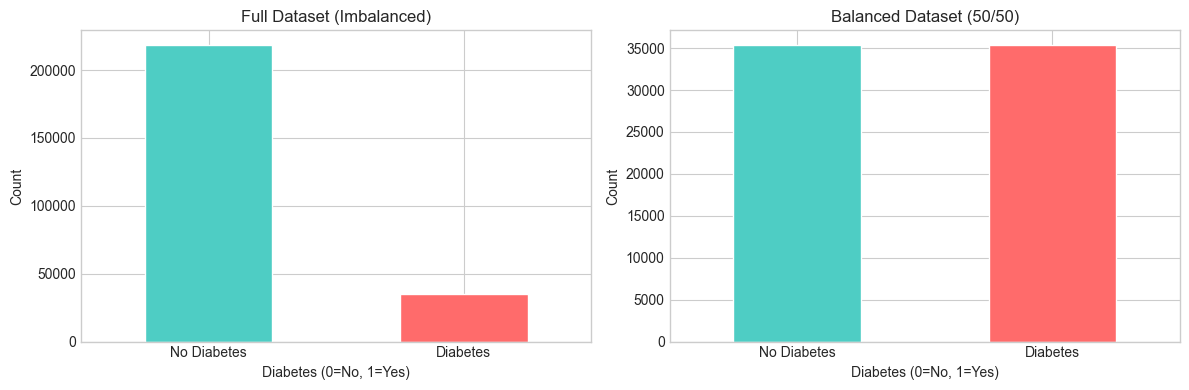

In [5]:
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_full['Diabetes_binary'].value_counts().plot(kind='bar', ax=axes[0], color=['#4ECDC4', '#FF6B6B'])
axes[0].set_title('Full Dataset (Imbalanced)')
axes[0].set_xlabel('Diabetes (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)

df['Diabetes_binary'].value_counts().plot(kind='bar', ax=axes[1], color=['#4ECDC4', '#FF6B6B'])
axes[1].set_title('Balanced Dataset (50/50)')
axes[1].set_xlabel('Diabetes (0=No, 1=Yes)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)

plt.tight_layout()
plt.savefig('figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

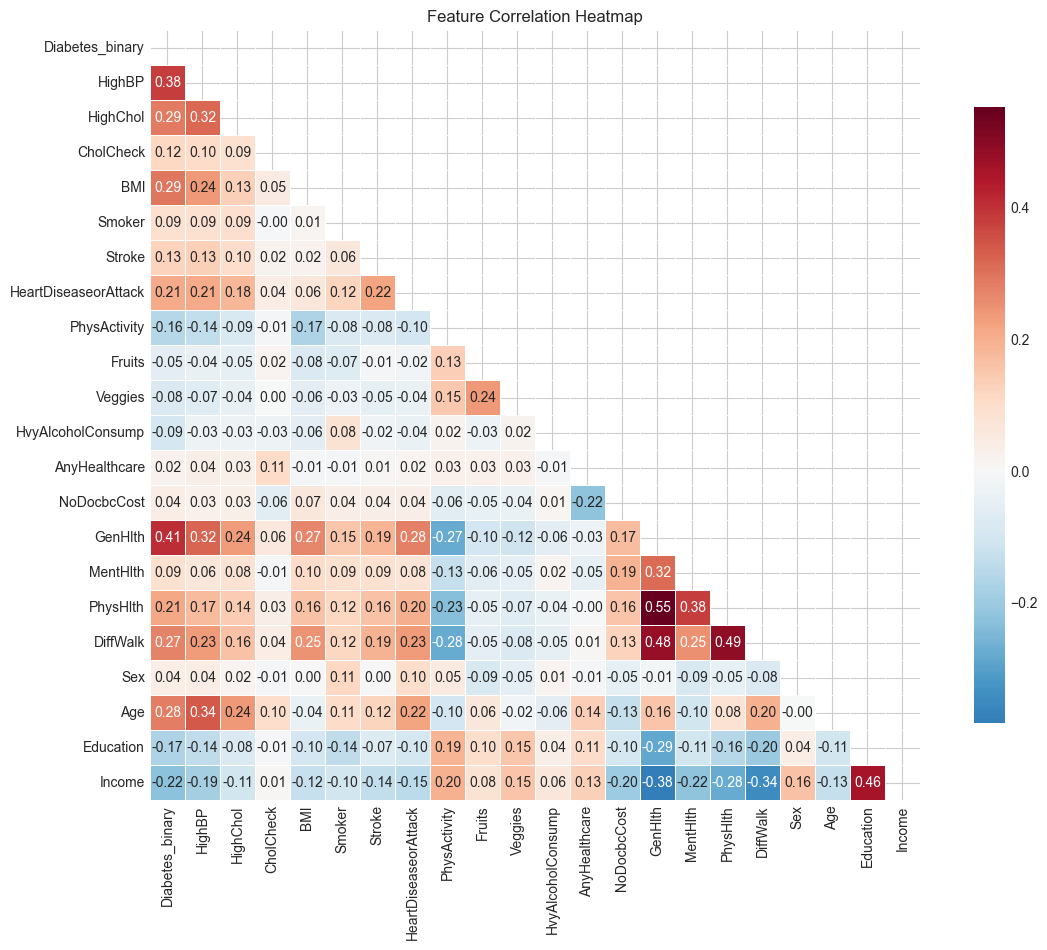

In [6]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation with Diabetes_binary (sorted):
GenHlth                 0.4076
HighBP                  0.3815
BMI                     0.2934
HighChol                0.2892
Age                     0.2787
DiffWalk                0.2726
PhysHlth                0.2131
HeartDiseaseorAttack    0.2115
Stroke                  0.1254
CholCheck               0.1154
MentHlth                0.0870
Smoker                  0.0860
Sex                     0.0444
NoDocbcCost             0.0410
AnyHealthcare           0.0232
Fruits                 -0.0541
Veggies                -0.0793
HvyAlcoholConsump      -0.0949
PhysActivity           -0.1587
Education              -0.1705
Income                 -0.2244
Name: Diabetes_binary, dtype: float64


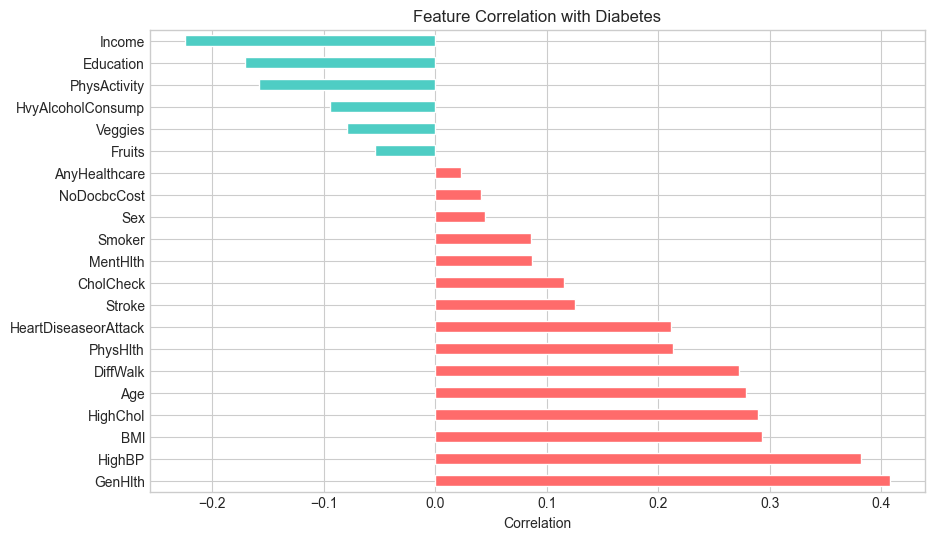

In [7]:
# Correlation with target (sorted)
target_corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)
print('Correlation with Diabetes_binary (sorted):')
print(target_corr.round(4))

plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh', color=['#FF6B6B' if x > 0 else '#4ECDC4' for x in target_corr])
plt.title('Feature Correlation with Diabetes')
plt.xlabel('Correlation')
plt.savefig('figures/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

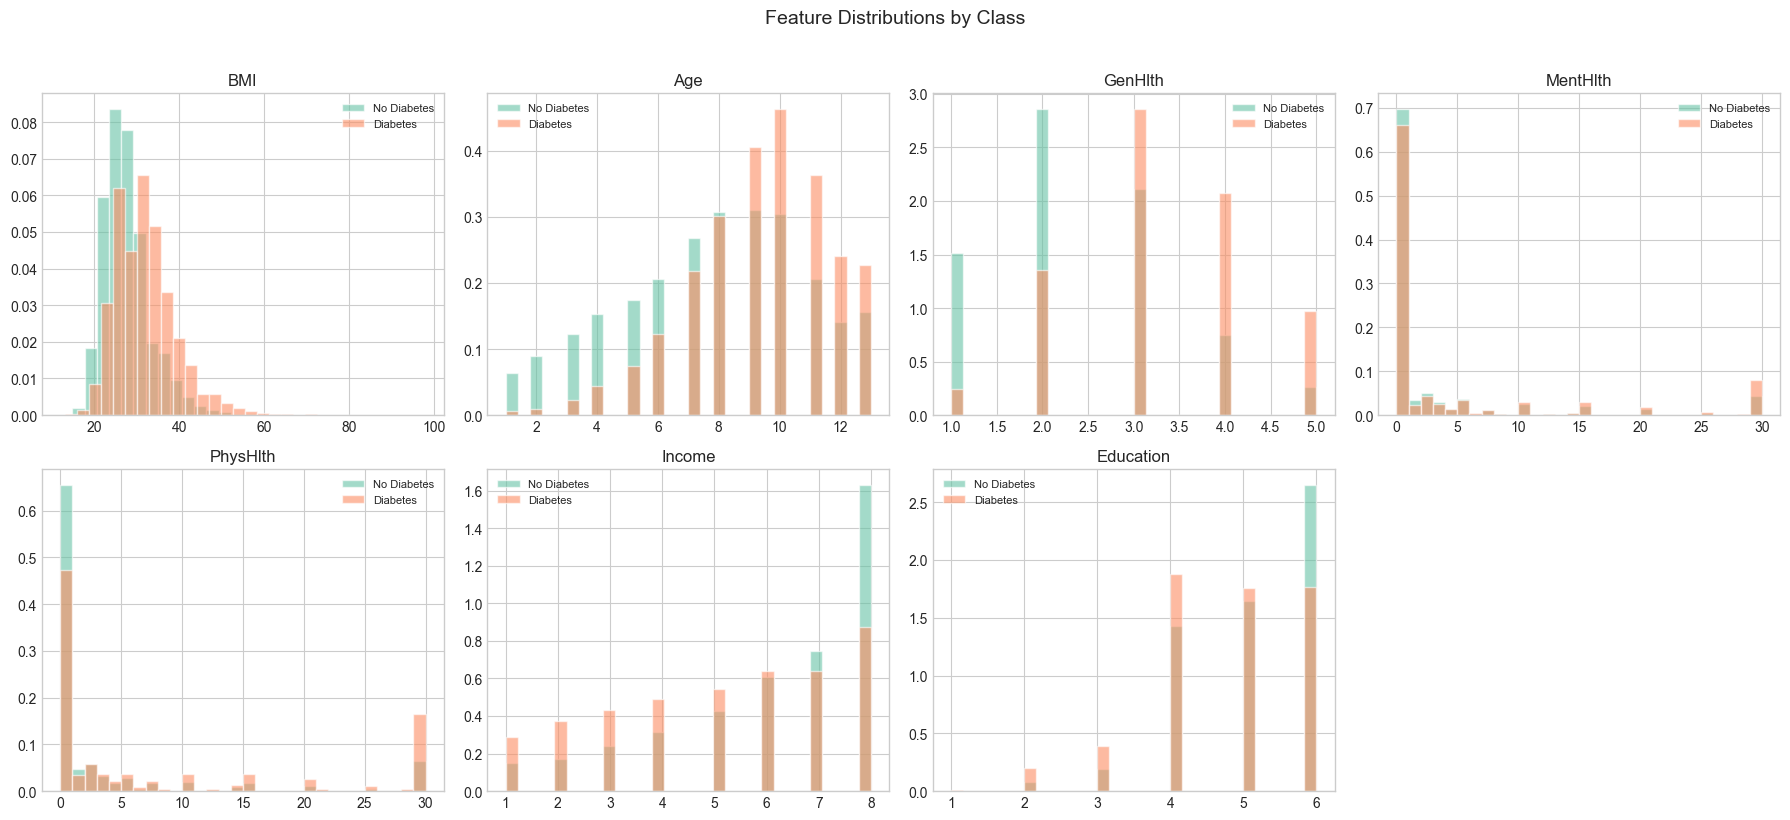

In [8]:
# Distribution of key features by class
features_to_plot = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth', 'Income', 'Education']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    for label in [0, 1]:
        subset = df[df['Diabetes_binary'] == label][feature]
        axes[i].hist(subset, bins=30, alpha=0.6,
                     label='Diabetes' if label == 1 else 'No Diabetes',
                     density=True)
    axes[i].set_title(feature)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

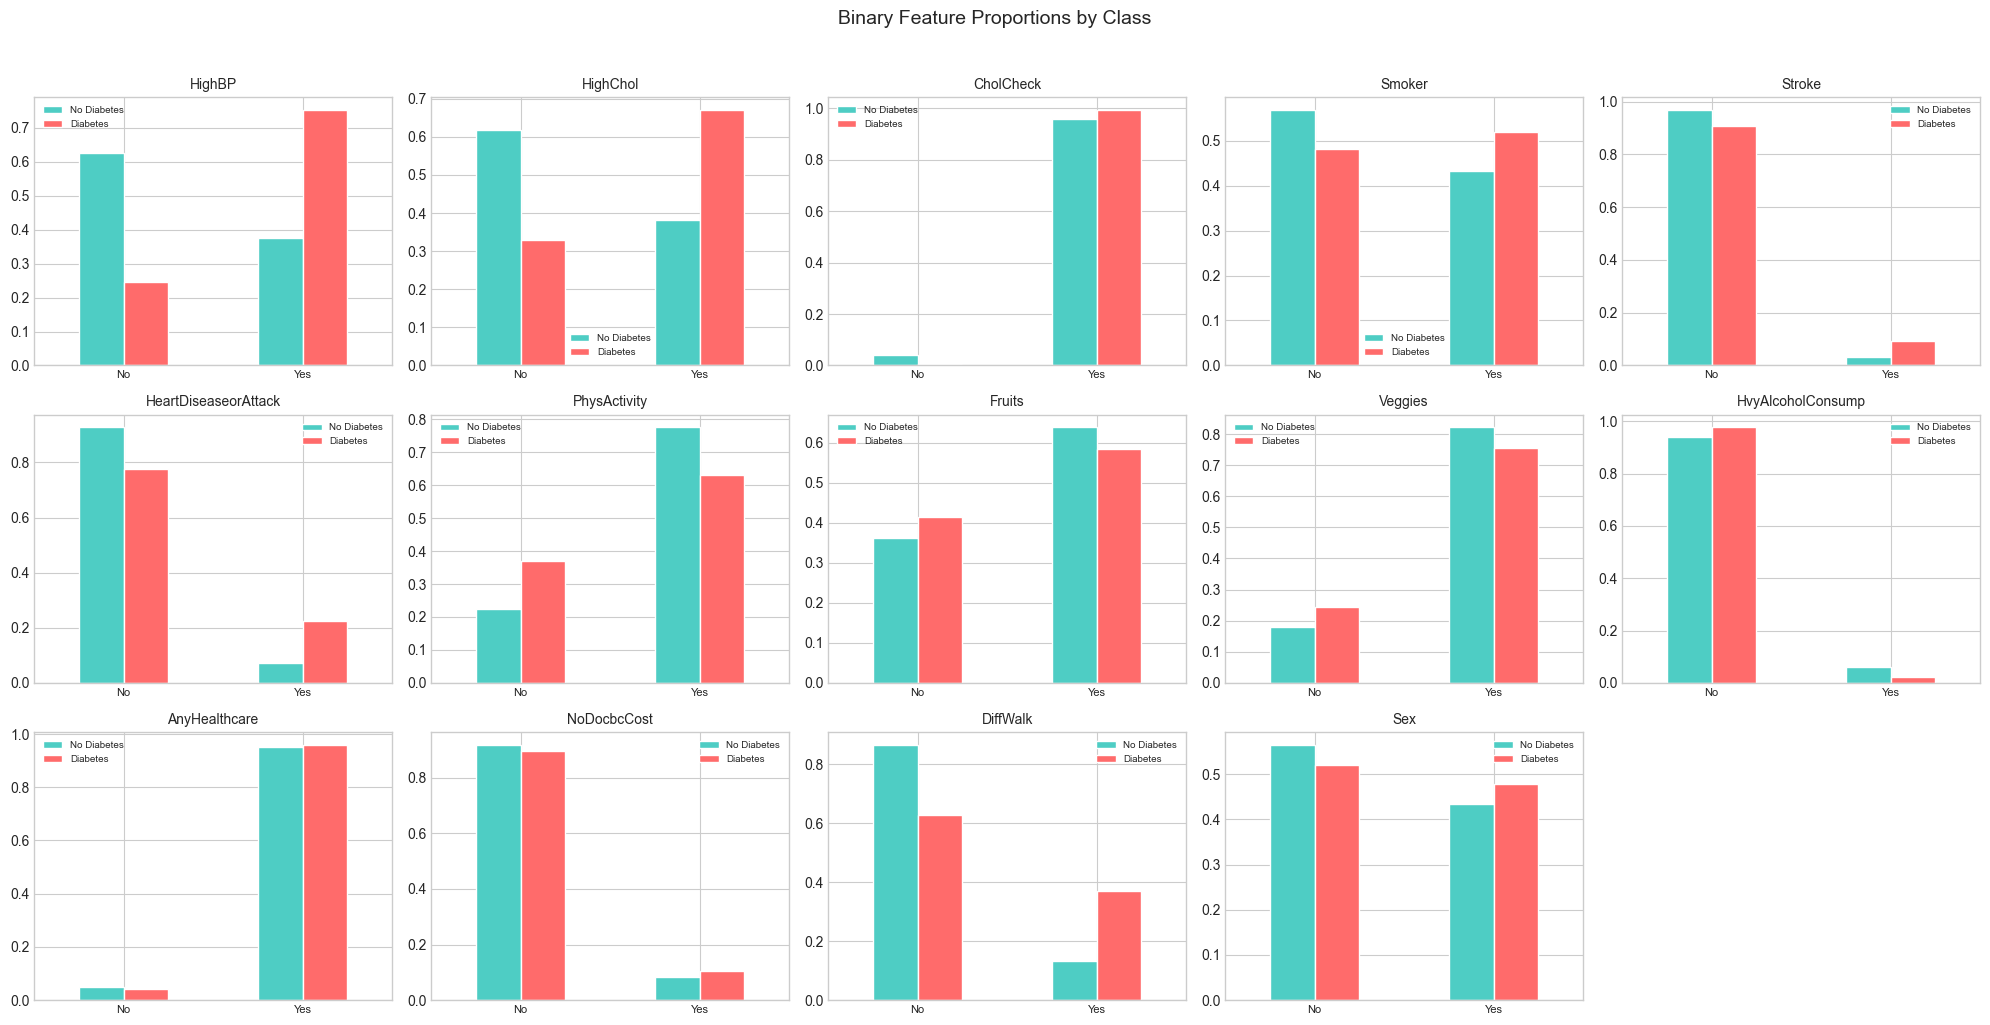

In [9]:
# Binary features distribution by class
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(binary_features):
    pd.crosstab(df[feature], df['Diabetes_binary'], normalize='columns').plot(
        kind='bar', ax=axes[i], stacked=False, color=['#4ECDC4', '#FF6B6B'])
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].legend(['No Diabetes', 'Diabetes'], fontsize=7)
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0, fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Binary Feature Proportions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/binary_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Preparation

In [10]:
# Split features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)
print()
print('Train target distribution:')
print(y_train.value_counts())
print()
print('Test target distribution:')
print(y_test.value_counts())

Training set: (56553, 21)
Test set: (14139, 21)

Train target distribution:
Diabetes_binary
1.0    28277
0.0    28276
Name: count, dtype: int64

Test target distribution:
Diabetes_binary
0.0    7070
1.0    7069
Name: count, dtype: int64


In [11]:
# Scale features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

## 4. Feature Selection — Random Forest

Random Forest Feature Importances:
BMI                     0.1723
Age                     0.1263
GenHlth                 0.1080
Income                  0.0838
HighBP                  0.0740
PhysHlth                0.0684
Education               0.0583
MentHlth                0.0510
HighChol                0.0412
Fruits                  0.0282
Smoker                  0.0281
Sex                     0.0263
DiffWalk                0.0254
PhysActivity            0.0225
Veggies                 0.0219
HeartDiseaseorAttack    0.0192
NoDocbcCost             0.0121
Stroke                  0.0099
HvyAlcoholConsump       0.0094
AnyHealthcare           0.0077
CholCheck               0.0061
dtype: float64


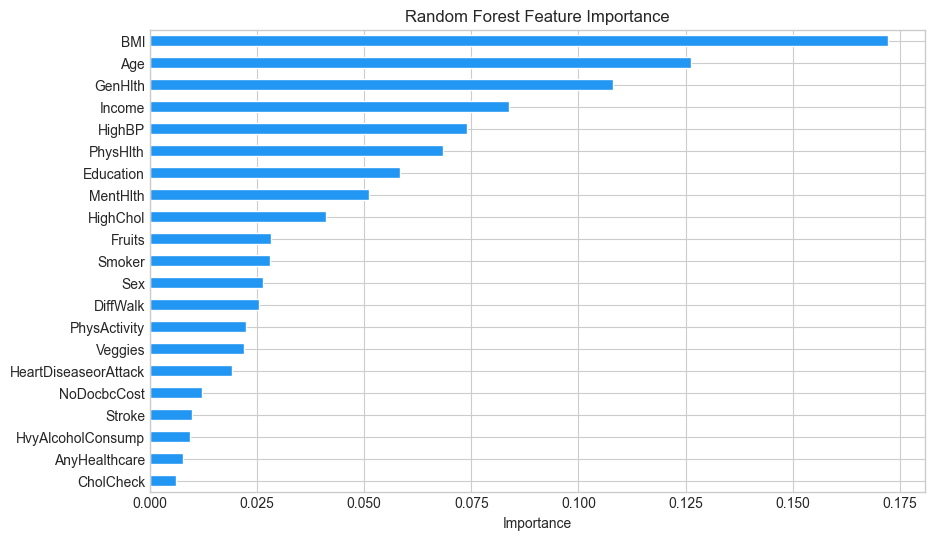

In [12]:
# Train Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Random Forest Feature Importances:')
print(importances.round(4))

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#2196F3')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.savefig('figures/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Top-K feature selection: compare performance with different numbers of features
top_features = importances.index.tolist()

results = []
for k in [4, 6, 8, 10, 14, 21]:
    selected = top_features[:k]
    X_train_k = X_train_scaled[selected]
    scores = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                             X_train_k, y_train, cv=5, scoring='f1')
    results.append({'k': k, 'features': ', '.join(selected),
                    'f1_mean': scores.mean(), 'f1_std': scores.std()})

results_df = pd.DataFrame(results)
print('Logistic Regression performance with top-K features (5-fold CV):')
print(results_df[['k', 'f1_mean', 'f1_std']].to_string(index=False))
print()
for _, row in results_df.iterrows():
    print(f"Top {int(row['k'])} features: {row['features']}")

Logistic Regression performance with top-K features (5-fold CV):
 k  f1_mean   f1_std
 4 0.731501 0.003193
 6 0.744779 0.003057
 8 0.744884 0.002882
10 0.749848 0.001637
14 0.750946 0.002570
21 0.753804 0.002368

Top 4 features: BMI, Age, GenHlth, Income
Top 6 features: BMI, Age, GenHlth, Income, HighBP, PhysHlth
Top 8 features: BMI, Age, GenHlth, Income, HighBP, PhysHlth, Education, MentHlth
Top 10 features: BMI, Age, GenHlth, Income, HighBP, PhysHlth, Education, MentHlth, HighChol, Fruits
Top 14 features: BMI, Age, GenHlth, Income, HighBP, PhysHlth, Education, MentHlth, HighChol, Fruits, Smoker, Sex, DiffWalk, PhysActivity
Top 21 features: BMI, Age, GenHlth, Income, HighBP, PhysHlth, Education, MentHlth, HighChol, Fruits, Smoker, Sex, DiffWalk, PhysActivity, Veggies, HeartDiseaseorAttack, NoDocbcCost, Stroke, HvyAlcoholConsump, AnyHealthcare, CholCheck


## 5. Baseline Model — Logistic Regression (All Features)

In [14]:
# Baseline: Logistic Regression with all features
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

y_pred = lr_baseline.predict(X_test_scaled)
y_prob = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print('=== Baseline Logistic Regression (All 21 Features) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

=== Baseline Logistic Regression (All 21 Features) ===
Accuracy:  0.7458
Precision: 0.7372
Recall:    0.7639
F1 Score:  0.7503
AUC-ROC:   0.8232

              precision    recall  f1-score   support

 No Diabetes       0.76      0.73      0.74      7070
    Diabetes       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



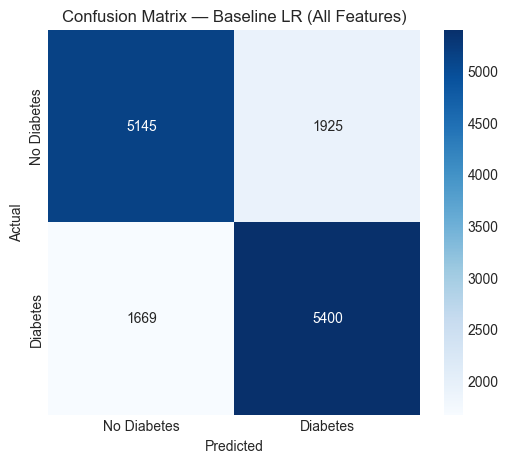

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Baseline LR (All Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('figures/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

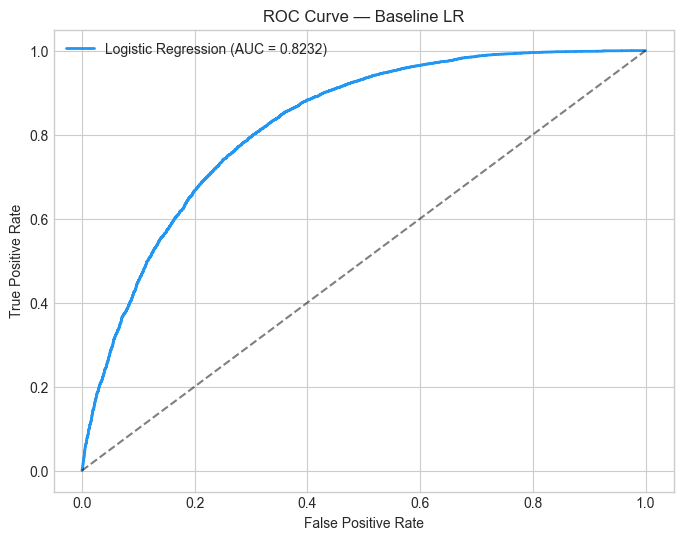

In [16]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.4f})',
         color='#2196F3', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline LR')
plt.legend()
plt.savefig('figures/roc_curve_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Baseline Model — Logistic Regression (Selected Features)

After comparing with L1 feature selection results from groupmate, we'll use the agreed-upon features here.

In [17]:
# TODO: Replace with agreed-upon features after comparing with groupmate's L1 results
# For now, using top features from Random Forest
selected_features = top_features[:4]  # Will update after group discussion
print(f'Selected features: {selected_features}')

X_train_sel = X_train_scaled[selected_features]
X_test_sel = X_test_scaled[selected_features]

lr_selected = LogisticRegression(max_iter=1000, random_state=42)
lr_selected.fit(X_train_sel, y_train)

y_pred_sel = lr_selected.predict(X_test_sel)
y_prob_sel = lr_selected.predict_proba(X_test_sel)[:, 1]

print(f'\n=== Logistic Regression (Selected Features) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_sel):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_sel):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_sel):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_sel):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_sel):.4f}')

Selected features: ['BMI', 'Age', 'GenHlth', 'Income']

=== Logistic Regression (Selected Features) ===
Accuracy:  0.7240
Precision: 0.7204
Recall:    0.7322
F1 Score:  0.7263
AUC-ROC:   0.7991


In [18]:
# Comparison: All features vs Selected features
print('=== Comparison ===')
print(f"{'Metric':<12} {'All Features':>15} {'Selected Features':>18}")
print('-' * 47)
for metric_name, all_val, sel_val in [
    ('Accuracy', accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_sel)),
    ('Precision', precision_score(y_test, y_pred), precision_score(y_test, y_pred_sel)),
    ('Recall', recall_score(y_test, y_pred), recall_score(y_test, y_pred_sel)),
    ('F1 Score', f1_score(y_test, y_pred), f1_score(y_test, y_pred_sel)),
    ('AUC-ROC', roc_auc_score(y_test, y_prob), roc_auc_score(y_test, y_prob_sel)),
]:
    print(f'{metric_name:<12} {all_val:>15.4f} {sel_val:>18.4f}')

=== Comparison ===
Metric          All Features  Selected Features
-----------------------------------------------
Accuracy              0.7458             0.7240
Precision             0.7372             0.7204
Recall                0.7639             0.7322
F1 Score              0.7503             0.7263
AUC-ROC               0.8232             0.7991


## 7. Summary & Next Steps

**What's done:**
- EDA on balanced diabetes dataset (70K records, 50/50 split)
- Random Forest feature importance ranking
- Baseline Logistic Regression with all features and selected features

**Next steps:**
- Compare RF feature selection with groupmate's L1 (Lasso) results
- Agree on shared feature set
- Update Section 6 with final selected features
- Pass balanced dataset + shared features to Ayelet & Nikunj for their models